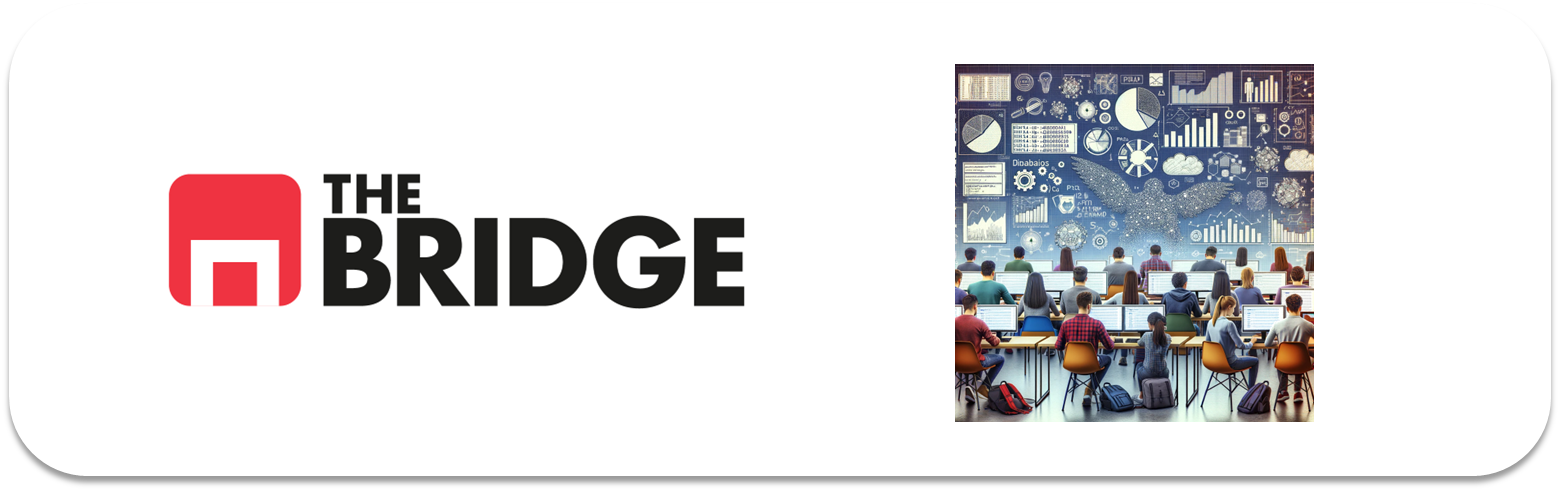

## PRACTICA OBLIGATORIA: **Estadistica Inferencial y Probabilidad**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [13]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_1samp

import matplotlib.pyplot as plt
from IPython.display import Image, display

## #1 Titanic

Carga el dataset del titanic, y contesta a las siguientes preguntas:

1. ¿Cuál es la probabilidad de superviviencia de un niño?
2. ¿Cuál es la probabilidad de que una mujer viajase sola?
3. ¿Cuál es la probabilidad de sobreviviese un hombre entre 30 y 40 años que embarcó en Southampton y no tuvo que pagar billete?
4. ¿Y si hubiera acompañado de 2 familiares?
5. Si consideramos ahora que queremos tener cierta confianza estadística en nuestras probabilidades (ten en cuenta que estamos extrapolando los ratios de una muestra), ¿cuál sería el rango de probabilidades de sobrevivir de una persona que viajase sola al 95%?
6. EXTRA: ¿Y si además el pasajero de 5 fuera un pasajero de tercera o de segunda?

In [14]:
titanic = pd.read_csv("data/titanic.csv")

titanic.head()

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


In [27]:
p_nino = (
    titanic.loc[
        titanic["who"] == "child",
        "alive"
    ] == "yes"
).mean()

print(f"Probabilidad: {p_nino:.4f}")

Probabilidad: 0.5904


In [16]:
p_mujer_sola = titanic.loc[
    (titanic["sex"] == "female") &
    (titanic["alone"] == True)
].shape[0] / len(titanic)

print(f"Probabilidad: {p_mujer_sola:.4f}")

Probabilidad: 0.1414


In [28]:
filtro = (
    (titanic["sex"] == "male") &
    (titanic["age"].between(30, 40)) &
    (titanic["embark_town"] == "Southampton") &
    (titanic["fare"] == 0)
)

prob = (
    titanic.loc[filtro, "alive"] == "yes"
).mean()

print(prob)

0.0


In [29]:
filtro = (
    (titanic["sex"] == "male") &
    (titanic["age"].between(30, 40)) &
    (titanic["embark_town"] == "Southampton") &
    (titanic["fare"] == 0) &
    ((titanic["sibsp"] + titanic["parch"]) == 2)
)

prob = (
    titanic.loc[filtro, "alive"] == "yes"
).mean()

print(prob)

nan


In [30]:
viaja_solo = titanic[titanic["alone"]]

p = (viaja_solo["alive"] == "yes").mean()

n = len(viaja_solo)

error = 1.96 * np.sqrt((p * (1 - p)) / n)

print("Probabilidad:", p)
print("Límite inferior:", p - error)
print("Límite superior:", p + error)

Probabilidad: 0.30353817504655495
Límite inferior: 0.264649401563202
Límite superior: 0.3424269485299079


In [31]:
prob = (
    titanic.loc[
        (titanic["alone"]) &
        (titanic["class"] == "Third"),
        "alive"
    ] == "yes"
).mean()

print(prob)

0.21296296296296297


## #2 Life Satisfaction

Carga el dataset de satifacción vital y contesta a las siguietnes preguntas:

1. ¿Podemos asegurar con cierta confianza estadística (del 99%) que la satisfaccion vital media del mundo es menor de 7?
2. ¿Qué nivel de satisfacción media asignaríamos a país con esperanza de vida de más de 65 años y tasa de empleo superior a 60%? (ojo fijate que son umbrales)
3. ¿Cuál sería la probabilidad de tener más de 6 puntos de satisfacción vital para los países con esperanza de vida mayor a 65 años y tasa de empleo superior a 60%?


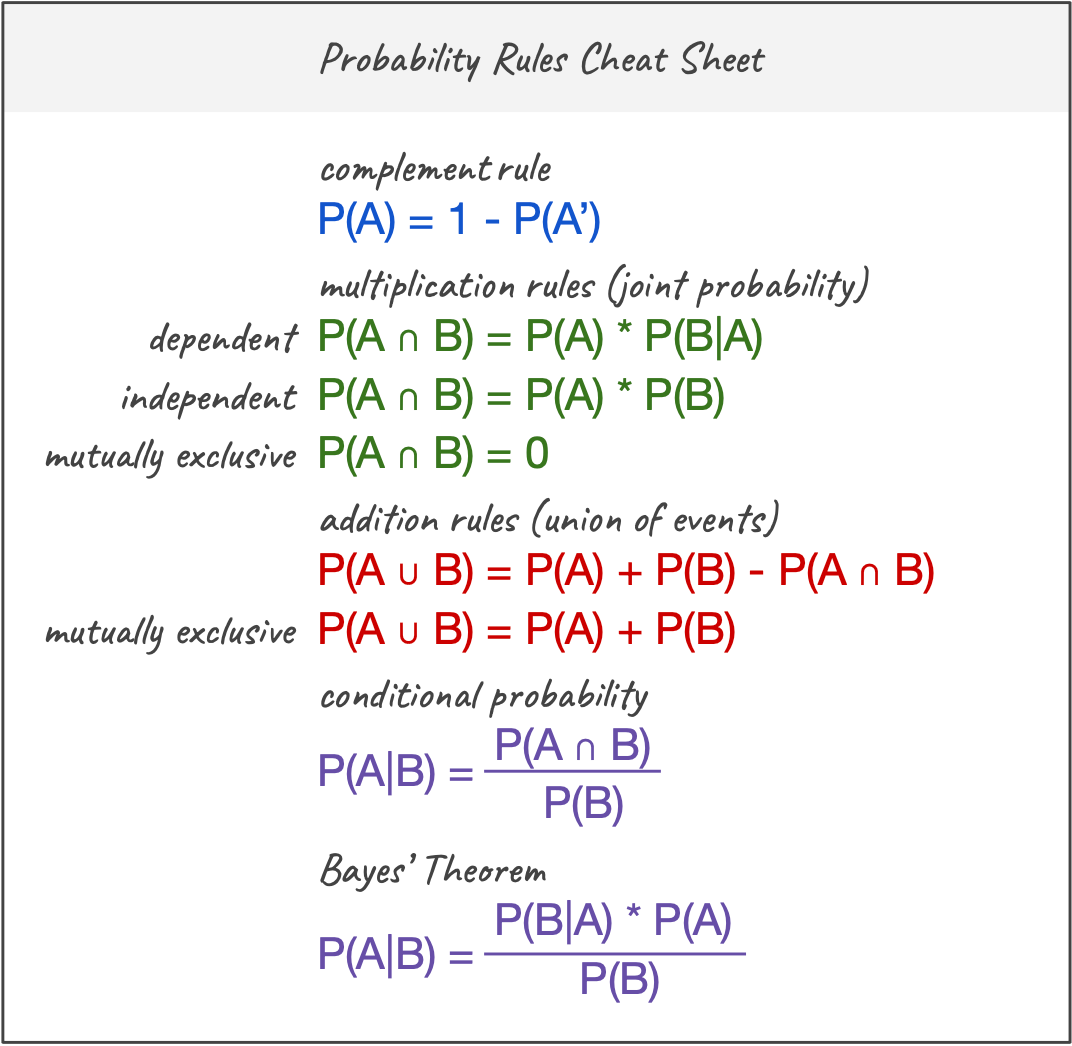

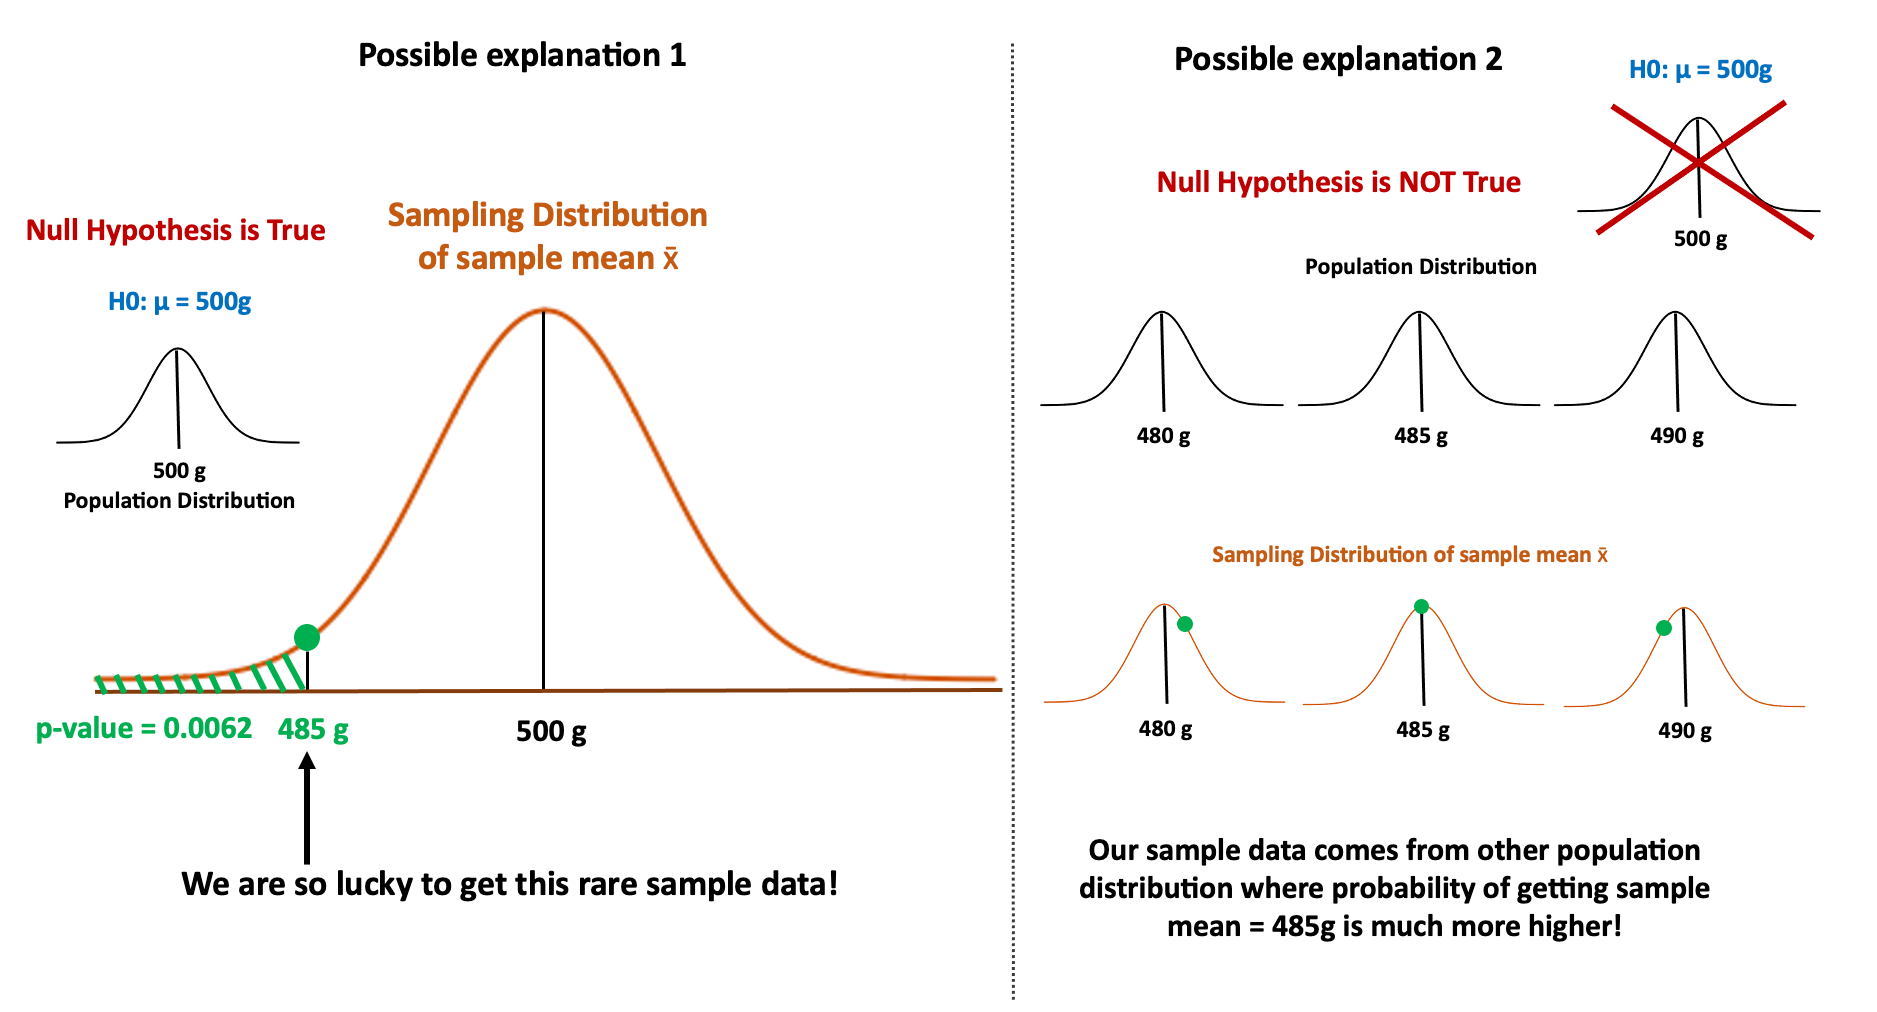

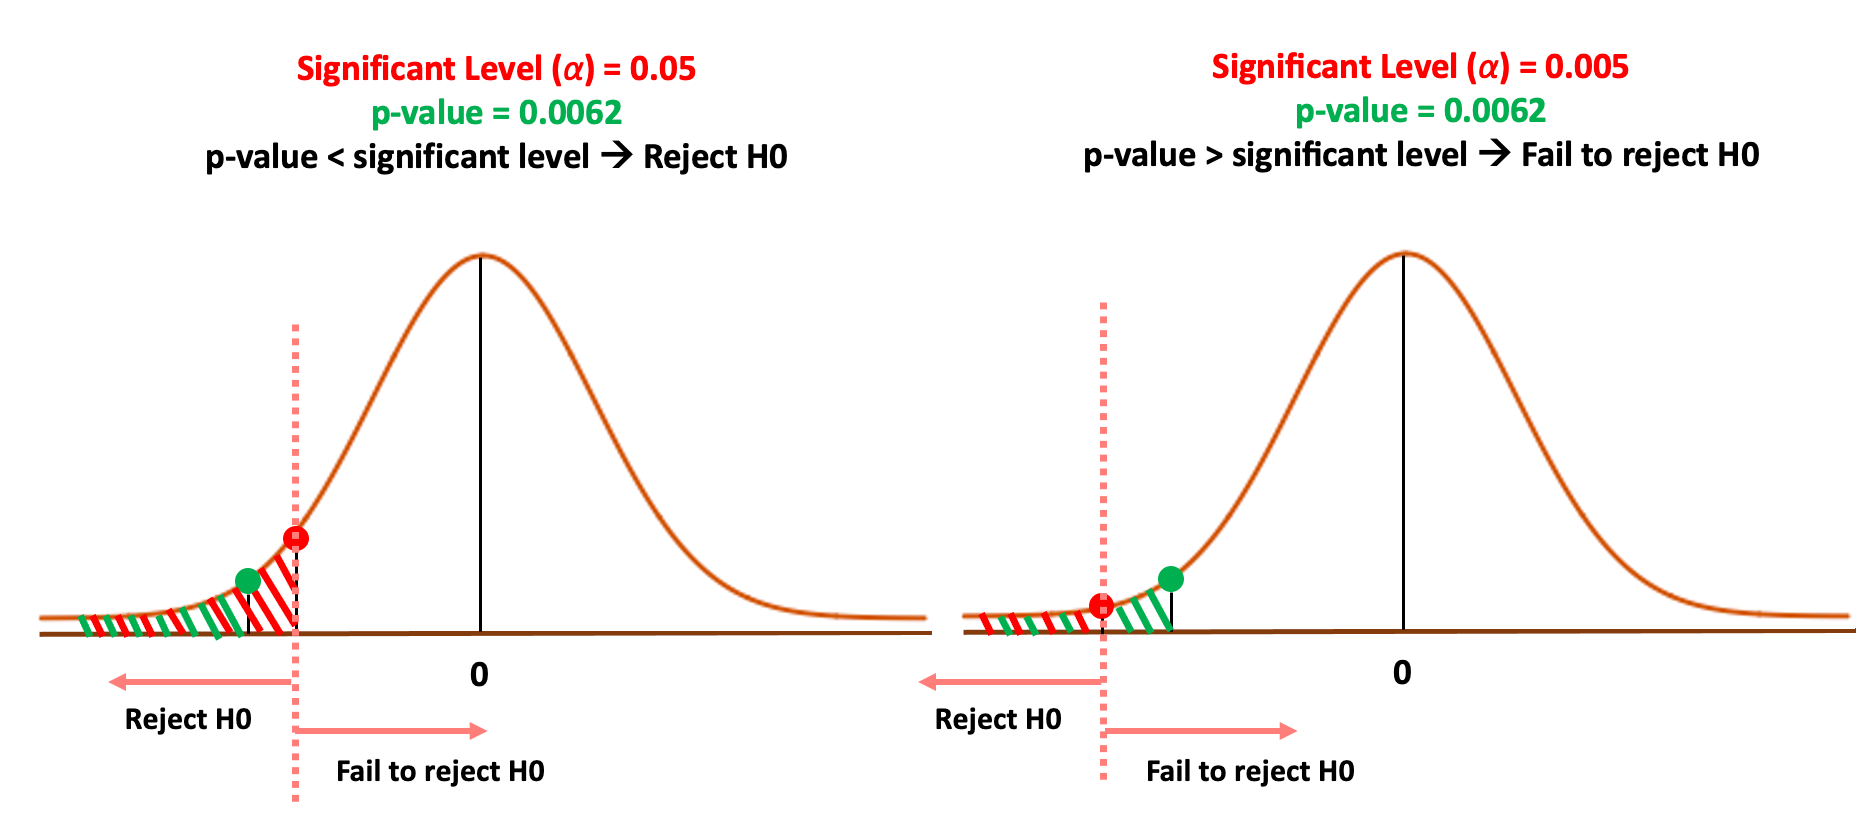

In [22]:
life = pd.read_csv("data/lifesat_full.csv")

life.head()

display(Image("recursos/probabilities.png"))

display(Image("recursos/p-value.png"))

display(Image("recursos/p-value2.png"))

In [24]:
resultado = ttest_1samp(
    life["Life satisfaction"],
    popmean=7,
    alternative="less"
)

print(resultado)

alpha = 0.01

if resultado.pvalue < alpha:
    print("Se rechaza H0.")
    print("La satisfacción media mundial es menor de 7.")
else:
    print("No se rechaza H0.")

TtestResult(statistic=np.float64(-3.0905237114679207), pvalue=np.float64(0.001951991770468331), df=np.int64(35))
Se rechaza H0.
La satisfacción media mundial es menor de 7.


In [25]:
filtro = (
    (life["Life expectancy"] > 65) &
    (life["Employment rate"] > 60)
)

media = life.loc[
    filtro,
    "Life satisfaction"
].mean()

print(media)

6.74614501634108


In [26]:
filtro = (
    (life["Life expectancy"] > 65) &
    (life["Employment rate"] > 60)
)

prob = (
    life.loc[
        filtro,
        "Life satisfaction"
    ] > 6
).mean()

print(prob)

0.78125


## EXTRA: La contrainituividad de la probabilidad

Para poder lidiar con la incertidumbre que nos rodea, **solemos aplicar lo que llamamos nuestro "*sentido común*"**. Por ejemplo, si al levantarnos por la mañana vemos que el día se encuentra nublado, este hecho no nos da la **certeza** de que comenzará a llover más tarde; sin embargo, nuestro *sentido común* puede inducirnos a cambiar nuestros planes y a actuar como si *creyéramos* que fuera a llover si las nubes son los suficientemente oscuras o si escuchamos truenos, ya que nuestra experiencia nos dice que estos signos indicarían una mayor *posibilidad* de que el hecho de que fuera a llover más tarde realmente ocurra. 
Nuestro *sentido común* es algo tan arraigado en nuestro pensamiento, que lo utilizamos automáticamente sin siquiera ponernos a pensar en ello; pero muchas veces, el *sentido común* también nos puede jugar una mala pasada y hacernos elegir una respuesta incorrecta.


#### Situación 1 - La coincidencia de cumpleaños
Vamos a una fiesta a la que concurren un total de 50 personas. Allí un amigo nos desafía afirmando que en la fiesta debe haber por lo menos 2 personas que cumplen años el mismo día y nos apuesta 100 euros a que está en lo correcto. Es decir, que si él acierta deberíamos pagarle los 100 euros; o en caso contrario, el nos pagará los 100 euros. ¿Deberíamos aceptar la apuesta? 


#### Situación 2 - ¿Que puerta elegir? (El dilema de Monty Hall)
Estamos participando en un concurso en el cual se nos ofrece la posibilidad de elegir una entre tres puertas. Tras una de ellas se encuentra una ferrari ultimo modelo, y detrás de las otras dos hay una cabra; luego de elegir una puerta, el presentador del concurso abre una de las puertas restantes y muestra que hay una cabra (el presentador sabe que hay detrás de cada puerta). Luego de hacer esto, el presentador nos ofrece la posibilidad de cambiar nuestra elección inicial y quedarnos con la otra puerta que no habíamos elegido inicialmente. ¿Deberíamos cambiar o confiar en nuestra elección inicial?

¿Qué te diría su *sentido común* que deberían hacer en cada una de estas situaciones?

### Situación 1

Si estamos hablando de sentido común, lo primero que yo me preguntaría es si es una fiesta de cumpleaños de alguno de los presentes. Aparte de eso, la paradoja del cumpleaños esto ya lo ha calculado y tenemos las de perder. El sentido común dice que es poco probable, pero el sentido común también me dice que si sé que la paradoja del cumpleaños existe no debería aceptar la apuesta.

### Situación 2

El sentido común dice que da igual, las matemáticas dicen que en nuestra primera elección nos la estábamos jugando a un 33.33% del gran premio, y ahora estamos eligiendo entre dos puertas. Esto es más un dilema filosófico sobre si no cambiar de puerta cuenta o no como elegir una puerta (la misma), creo yo. A nivel de sentido común da igual en mi opinión, siempre que lo que haya detrás de las puertas no se mueva.